# LLM SPICE-in-the-Loop: Comparator Optimization
This notebook demonstrates how to automatically loop the LLM with ngspice simulations (Delay, Offset, and PVT) to fix and tune a comparator.

In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import sys, os
from pathlib import Path
root = Path("/foss/designs/chipathon2026-D")
sys.path.insert(0, str(root))

from core import (
    generate_netlist_from_prompt,
    run_comparator_tran, run_comparator_pvt,
    spice_to_gds, display_component
)

In [37]:
# Check API Key
from core.pipeline import _load_api_key
key = _load_api_key()
if key:
    print(f"API key loaded: {key[:10]}...")
else:
    print("WARNING: DEEPSEEK_API_KEY not set!")

API key loaded: sk-81ba887...


In [38]:
prompt = """
Design a clocked StrongARM latch comparator.
Use gf180mcuD PDK with 1.8V supply.
The circuit should have:
- Clock frequency: 1 MHz
- Input common-mode voltage: 0.9V
- Input differential offset voltage: 0.01V
- Delay propagation less than 250ns
- The Comparator architecture is flexible (e.g., StrongARM latch, double-tail latch, time-domain comparator, etc.) but must meet the above specifications.
Subcircuit name: my_comp
Ports: vin_p, vin_n, clk, vout_p, vout_n, vdd, vss

Example SPICE netlist for a StrongARM latch comparator:

.lib "/home/huda/.volare/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical
.subckt my_comp vin_p vin_n clk vout_p vout_n vdd vss
Mtail n1 clk vss vss nfet_03v3 W=8u L=0.5u
M2 n2 vin_p n1 vss nfet_03v3 W=10u L=0.5u
M3 n3 vin_n n1 vss nfet_03v3 W=10u L=0.5u
M4 n2 n3 vdd vdd pfet_03v3 W=4u L=0.5u
M5 n3 n2 vdd vdd pfet_03v3 W=4u L=0.5u
M6 n2 n3 n1 vss nfet_03v3 W=3u L=0.5u
M7 n3 n2 n1 vss nfet_03v3 W=3u L=0.5u
M8 n2 clk vdd vdd pfet_03v3 W=2u L=0.5u
M9 n3 clk vdd vdd pfet_03v3 W=2u L=0.5u
M10 vout_p n2 vdd vdd pfet_03v3 W=4u L=0.5u
M11 vout_p n2 vss vss nfet_03v3 W=2u L=0.5u
M12 vout_n n3 vdd vdd pfet_03v3 W=4u L=0.5u
M13 vout_n n3 vss vss nfet_03v3 W=2u L=0.5u
.ends

Please generate the SPICE netlist for this comparator design based on the specifications provided above and make any necessary adjustments and improvements.
"""
print("Generating initial netlist...")
netlist = generate_netlist_from_prompt(prompt)
print("\n--- Initial Netlist ---\n", netlist)

Generating initial netlist...
[LLM] Response: 3661 bytes
[LLM] Raw (649 chars):
.lib "/home/huda/.volare/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical
.subckt my_comp vin_p vin_n clk vout_p vout_n vdd vss
Mtail n1 clk vss vss nfet_03v3 W=8u L=1u
M2 n2 vin_p n1 vss nfet_03v3 W=10u L=1u
M3 n3 vin_n n1 vss nfet_03v3 W=10u L=1u
M4 n2 n3 vdd vdd pfet_03v3 W=4u L=1u
M5 n3 n2 
[LLM] Cleaned (16 lines):
.lib "/home/huda/.volare/gf180mcuD/libs.tech/ngspice/sm141064.ngspice" typical
.subckt my_comp vin_p vin_n clk vout_p vout_n vdd vss
Mtail n1 clk vss vss nfet_03v3 W=8u L=1u
M2 n2 vin_p n1 vss nfet_03v3 W=10u L=1u
M3 n3 vin_n n1 vss nfet_03v3 W=10u L=1u
M4 n2 n3 vdd vdd pfet_03v3 W=4u L=1u
M5 n3 n2 vdd vdd pfet_03v3 W=4u L=1u
M6 n2 n3 n1 vss nfet_03v3 W=3u L=1u
M7 n3 n2 n1 vss nfet_03v3 W=3u L=1u
M8 n2 clk vdd vdd pfet_03v3 W=2u L=1u
M9 n3 clk vdd vdd pfet_03v3 W=2u L=1u
M10 vout_p n2 vdd vdd pfet_03v3 W=4u L=1u
M11 vout_p n2 vss vss nfet_03v3 W=2u L=1u
M12 vout_n n3 vdd vdd pfet_03v3 W

In [ ]:
import json
import uuid
import datetime as _datetime

max_iters = 10
iter_count = 0
finetune_needed = True
netlist_retries = 0
max_netlist_retries = 5
cell_name = "my_comp"
session_history = []
session_id = _uuid.uuid4().hex[:12]
session_start = _datetime.datetime.now().isoformat()

# Track the best netlist across iterations
best_netlist = None
best_score = float('inf')  # lower is better
best_metrics = {}

dataset_messages = [
    {"role": "system", "content": "You are an analog IC design expert. Generate valid SPICE subcircuit netlists for GF180MCU (0.18um) PDK. Use nfet_03v3 and pfet_03v3 models with 1.8V supply. Respond ONLY with the netlist, no explanations."},
]

def _score(vos, tdelay, pvt_pass):
    """Compute score: lower is better. Penalize heavily for N/A values."""
    s = 0.0
    if vos is None:
        s += 100.0
    else:
        s += abs(vos) * 1000  # scale mV
    if tdelay is None:
        s += 100.0
    else:
        s += tdelay * 1e10   # scale to ~0.1-1 range
    if not pvt_pass:
        s += 50
    return s

while finetune_needed and iter_count < max_iters:
    print(f"\n" + "="*40)
    print(f"=== SIMULATION ITERATION {iter_count} ===")
    print("="*40)
    
    if not netlist:
        netlist_retries += 1
        if netlist_retries > max_netlist_retries:
            print(f"\n[!!] Failed to generate valid netlist after {max_netlist_retries} retries. Aborting.")
            break
        print(f"\n[!] Netlist is empty or invalid. Regenerating (attempt {netlist_retries}/{max_netlist_retries})...")
        hist_info = ""
        if session_history:
            hist_info = "\nPreviously tried (all failed):\n" + "\n".join(
                f"  Iter {h['iter']}: {h.get('issues','?')[:120]}"
                for h in session_history[-3:]
            )
        fallback_fb = f"The previous netlist generation returned empty or was invalid.{hist_info}\nPlease generate a COMPLETE valid SPICE netlist with .subckt/.ends."
        netlist = generate_netlist_from_prompt(prompt, llm_feedback=fallback_fb)
        iter_count += 1
        continue
        
    netlist_retries = 0
    
    # Track netlist for dataset
    if iter_count == 0 and len(dataset_messages) == 1:
        dataset_messages.append({"role": "user", "content": prompt})
        dataset_messages.append({"role": "assistant", "content": netlist})
    elif len(dataset_messages) >= 1 and dataset_messages[-1]["role"] != "assistant":
        dataset_messages.append({"role": "assistant", "content": netlist})
    
    # 1. Delay Simulation
    pre = run_comparator_tran(netlist, cell_name, vdd=1.8, vcm=0.9, clk_period=1e-6, tstop=5e-6)
    
    # 2. Offset Simulation
    off = run_comparator_tran(netlist, cell_name, vdd=1.8, vcm=0.9, clk_period=1e-6, tstop=7e-6, measure_offset=True)
    
    # 3. PVT Simulation
    pvt = run_comparator_pvt(netlist, cell_name, vdd=1.8, vcm=0.9, clk_period=1e-6, tstop=5e-6)
    
    finetune_needed = pre.get('finetune', True) or off.get('finetune', True) or pvt.get('finetune', True)
    
    # Update best netlist tracking
    pvt_pass = not pvt.get('finetune', True)
    curr_score = _score(off.get('vos'), pre.get('tdelay'), pvt_pass)
    is_best = curr_score < best_score
    if is_best:
        best_score = curr_score
        best_netlist = netlist
        best_metrics = {
            'iter': iter_count, 'tdelay': pre.get('tdelay'),
            'vos': off.get('vos'), 'pvt_pass': pvt_pass, 'score': curr_score,
        }
        print(f"  [BEST] New best netlist! score={curr_score:.3f} (vos={off.get('vos')}, tdelay={pre.get('tdelay')}, pvt={pvt_pass})")
    
    if not finetune_needed:
        print("\n>>> SUCCESS! The comparator is fully functional across all PVT corners. <<<")
        print(f"\nSession completed in {iter_count} iterations.")
        for h in session_history:
            print(f"  Iter {h['iter']}: tdelay={h.get('tdelay')}, vos={h.get('vos')}")
        break
        
    print("\n[!] Comparator needs finetuning. Building session context...")
    
    import tempfile
    from core.simulation import _generate_comparator_testbench
    tb_dummy = _generate_comparator_testbench(netlist, cell_name, tempfile.mkdtemp(), vdd=1.8, vcm=0.9, clk_period=1e-6, tstop=5e-6)
    try:
        with open(tb_dummy, 'r') as f:
            tb_content = f.read()
    except:
        tb_content = "Testbench unavailable."
    
    current_feedback = (
        "=== CURRENT ITERATION (" + str(iter_count) + ") RESULTS ===\n"
        f"tdelay = {pre.get('tdelay', 'N/A')}\n"
        f"vos    = {off.get('vos', 'N/A')}\n"
        f"pvt_pass = {not pvt.get('finetune', True)}\n"
        + ("*** THIS IS THE BEST NETLIST SO FAR ***\n" if is_best else "") +
        "\n=== DELAY FEEDBACK ===\n" + pre.get("llm_feedback", "") + "\n\n" +
        "=== OFFSET FEEDBACK ===\n" + off.get("llm_feedback", "") + "\n\n" +
        "=== PVT FEEDBACK ===\n" + pvt.get("llm_feedback", "")
    )
    
    # Session history context
    session_context = "=== FINETUNE SESSION CONTEXT ===\n"
    session_context += "You are optimizing a StrongARM comparator. Below is the history of previous attempts that FAILED.\n"
    session_context += "DO NOT repeat any of these designs. Each iteration should try something different.\n\n"
    
    # Current best netlist reference
    if best_netlist:
        session_context += "=== CURRENT BEST NETLIST (Iteration " + str(best_metrics['iter']) + ") ===\n"
        session_context += f"Best metrics: vos={best_metrics.get('vos')}, tdelay={best_metrics.get('tdelay')}, pvt_pass={best_metrics.get('pvt_pass')}\n"
        session_context += "Use this as your STARTING POINT when improving. Only modify what needs fixing.\n"
        session_context += f"```spice\n{best_netlist}\n```\n\n"
    
    if session_history:
        session_context += f"--- PREVIOUS {len(session_history)} FAILED ATTEMPTS ---\n\n"
        for h in session_history[-5:]:
            session_context += (
                f"Iteration {h['iter']}:\n"
                f"  tdelay={h.get('tdelay','N/A')}, vos={h.get('vos','N/A')}\n"
                f"  Issues: {h.get('issues','none')[:200]}\n"
            )
        session_context += "\n--- END HISTORY ---\n\n"
    
    session_context += "=== SPICE TESTBENCH CONTEXT ===\n"
    session_context += "The circuit is tested with this testbench:\n"
    session_context += f"```spice\n{tb_content}\n```\n\n"
    session_context += current_feedback
    
    # Store feedback in dataset
    dataset_messages.append({"role": "user", "content": session_context})
    
    print(session_context[:2000] + ("...(truncated)" if len(session_context) > 2000 else ""))
    
    issues_summary = []
    if pre.get('finetune', True):
        issues_summary.append(f"delay:{pre.get('tdelay','fail')}")
    if off.get('finetune', True):
        issues_summary.append(f"vos:{off.get('vos','fail')}")
    if pvt.get('finetune', True):
        issues_summary.append("pvt:fail")
    
    session_history.append({
        'iter': iter_count,
        'netlist': netlist[:600],
        'tdelay': pre.get('tdelay'),
        'vos': off.get('vos'),
        'issues': '; '.join(issues_summary) or 'ok',
        'is_best': is_best,
    })
    
    print(f"\nSession memory: {len(session_history)} entries stored.")
    print("\nAsking LLM for a revised netlist with full session context...")
    
    new_netlist = generate_netlist_from_prompt(prompt, llm_feedback=session_context)
    if not new_netlist:
        print("[!] LLM returned empty netlist. Will retry generation on next iteration.")
    netlist = new_netlist
    iter_count += 1

# If we hit max iterations without success, use the best netlist found
if finetune_needed and best_netlist:
    print("\n========================================")
    print(f"[BEST] Using best netlist from iteration {best_metrics['iter']}")
    print(f"[BEST] Score: {best_score:.3f}, vos={best_metrics.get('vos')}, tdelay={best_metrics.get('tdelay')}")
    print("========================================")
    netlist = best_netlist  # Use best for final GDS
elif finetune_needed:
    print("\nWarning: Reached maximum iterations without any valid netlist.")
    if session_history:
        print(f"Session history ({len(session_history)} attempts) is available for review.")


# ---- Save Finetuning Dataset ----
if len(dataset_messages) > 2 and any(m["role"] == "assistant" for m in dataset_messages):
    dataset_dir = os.path.join(os.getcwd(), "dataset")
    os.makedirs(dataset_dir, exist_ok=True)
    session_file = os.path.join(dataset_dir, f"session_{session_id}.json")
    
    if dataset_messages[-1]["role"] == "user":
        dataset_messages.pop()
    
    dataset_entry = {
        "messages": dataset_messages,
        "metadata": {
            "session_id": session_id,
            "cell_name": cell_name,
            "started": session_start,
            "total_iterations": iter_count,
            "success": not finetune_needed,
            "pdk": "gf180mcuD",
            "best_metrics": best_metrics,
            "best_score": best_score,
            "history_count": len(session_history),
        }
    }
    with open(session_file, "w") as f:
        json.dump(dataset_entry, f, indent=2)
    
    print(f"\n========================================")
    print(f"[Dataset] Saved: {session_file}")
    print(f"[Dataset] {len(dataset_messages)} messages, {len(session_history)} iterations")
    print(f"[Dataset] Format: OpenAI/HuggingFace SFT compatible")
    print(f"========================================")
else:
    print("\n[Dataset] Not saved - insufficient data (no netlist generated).")


2026-07-05 05:02:33.681 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


Generating layout for the functional comparator...
[PIPELINE] PDK: gf180
{'name': 'tie_W_top_met_W', 'width': 23.82, 'center': [-4.475, 0.0], 'orientation': 180.0, 'layer': [34, 0], 'port_type': 'electrical'}
[LAYOUT] Sukses menempatkan Mtail (nfet_03v3) di posisi X: 0.0u, Y: 0.0u
{'name': 'tie_W_top_met_W', 'width': 33.82, 'center': [14.875, 0.0], 'orientation': 180.0, 'layer': [34, 0], 'port_type': 'electrical'}
[LAYOUT] Sukses menempatkan M2 (nfet_03v3) di posisi X: 19.349999999999998u, Y: 0.0u
{'name': 'tie_W_top_met_W', 'width': 33.82, 'center': [34.225, 0.0], 'orientation': 180.0, 'layer': [34, 0], 'port_type': 'electrical'}
[LAYOUT] Sukses menempatkan M3 (nfet_03v3) di posisi X: 38.699999999999996u, Y: 0.0u
[LAYOUT] Sukses menempatkan M4 (pfet_03v3) di posisi X: 9.675000000000004u, Y: 157.0u
[LAYOUT] Sukses menempatkan M5 (pfet_03v3) di posisi X: 29.025000000000002u, Y: 157.0u
{'name': 'tie_W_top_met_W', 'width': 9.81, 'center': [53.575, 0.0], 'orientation': 180.0, 'layer': [34,

2026-07-05 05:05:14.257 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/huda/Microelectronic-Block-Generator/designs/notebooks/chipathon2026-D/optimized_comparator.gds'
2026-07-05 05:05:14.265 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/huda/Microelectronic-Block-Generator/designs/notebooks/chipathon2026-D/out.gds'


[PIPELINE] Done: my_comp
Layout written to /home/huda/Microelectronic-Block-Generator/designs/notebooks/chipathon2026-D/optimized_comparator.gds


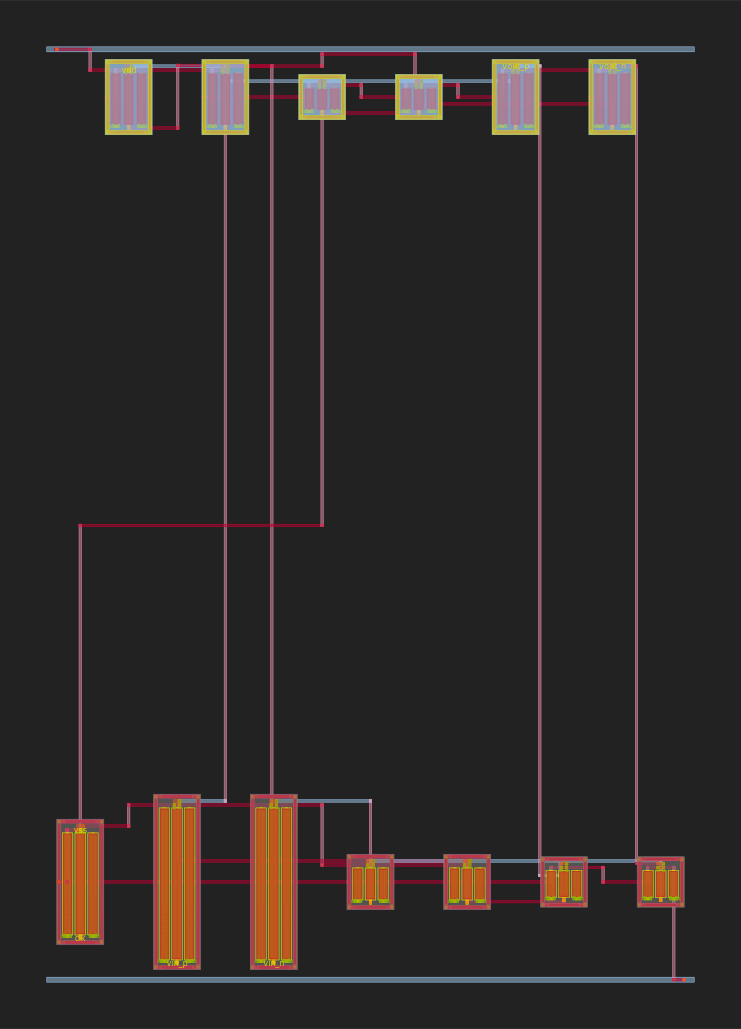

In [51]:
# If we achieved a good netlist, generate the final GDS
if  best_netlist:
    print("Generating layout for the functional comparator...")
    GDS_PATH = os.path.join(os.getcwd(), "optimized_comparator.gds")
    result = spice_to_gds(best_netlist, mode="analog", add_labels=True)
    result.write_gds(GDS_PATH)
    print(f"Layout written to {GDS_PATH}")
    display_component(result, scale=0.5)
